In [ ]:
# Import Libraries and Modules
import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [5]:
# Create model directories
os.makedirs("models/rf/train", exist_ok=True)
os.makedirs("models/dnn/train", exist_ok=True)
os.makedirs("models/lstm/train", exist_ok=True)

In [6]:
# Target column used for multiclass classification
TARGET_COL = "Attack Group"

# Columns excluded from feature set during training
DROP_COLS = ['Binary Label', 'Attack Group', 'Label', "Dataset"]

In [7]:
# Global Functions

def load_raw_data(path):
    """ Loads CSV dataset and reduces memory usage """

    print("Loading data...")
    df = pd.read_csv(path)

    return reduce_mem_usage(df)

def reduce_mem_usage(df):
    """ Downcasts numeric columns to reduce memory usage """

    # Iterate through all dataframe columns
    for col in df.columns:

        # Convert float64 to float32
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')

        # Convert int64 to int32
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    
    return df

def select_features(df, FEATURES=None):
    """ Splits dataset into features (X) and target label (Y) """

    # Selects features if provided
    if FEATURES is not None:
        X = df[FEATURES]

    # Otherwise use all columns except excluded columns 
    else:
        X = df.drop(columns=DROP_COLS, errors="ignore")
    
    # Extract target labels
    Y = df[TARGET_COL]
    
    return X, Y

def encode_labels(Y):
    """ Encodes target label into numeric values """

    print("Encoding Labels...")

    # Initialise label encoder
    encoder = LabelEncoder()

    # Transform labels into numeric representations
    Y = encoder.fit_transform(Y)

    return Y, encoder

def scale_features(X, method="standard"):
    """ Applies feature scaling to input features """

    print("Applying scaler...")

    # Standardise using standard scaler
    if method == "standard":
        scaler = StandardScaler()

    # Standardise using minmax scaler
    elif method == "minmax":
        scaler = MinMaxScaler()

    # Fit and transform features    
    X = scaler.fit_transform(X)

    return X, scaler

def apply_pca(X, n_components):
    """ Applies PCA for dimensionality reduction """

    print("Appling PCA...")

    # Initialise PCA model
    pca = PCA(n_components=n_components)

    # Transform features into principal components
    X = pca.fit_transform(X)

    return X, pca

90% variance retained with 23 components
95% variance retained with 28 components
99% variance retained with 36 components


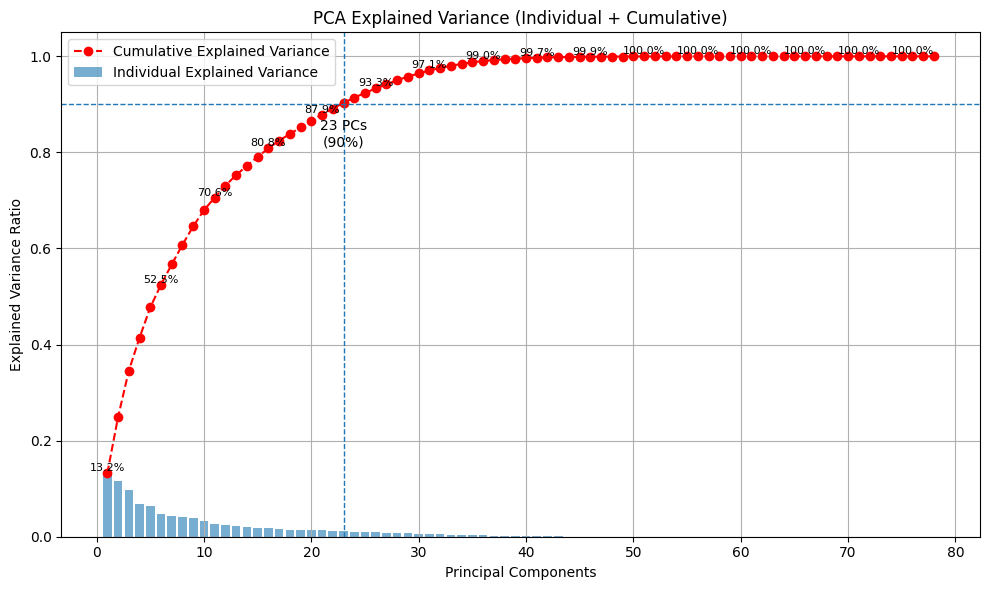

In [8]:
# PCA explained variance analysis

# Training dataset path
DATA = "data/cleaned/partitioned/balanced_train.csv"

# Load and optimise dataset memory usage
data_train = pd.read_csv(DATA)
data_train = reduce_mem_usage(data_train)

# Extract features
X_train = data_train.drop(columns=DROP_COLS, errors="ignore")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Initialise PCA
pca = PCA()
pca.fit(X_scaled)

# Individual explained variance per component
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Display number of components needed to retain 90% / 95% / 99% variance
for threshold in [0.90, 0.95, 0.99]:
    comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{int(threshold*100)}% variance retained with {comp} components")


plt.figure(figsize=(10, 6))

# X-axis values (principal component indices)
x_vals = range(1, len(cumulative_variance)+1)

# Individual wxplained variance (bar chart)
plt.bar(
    range(1, len(explained_variance)+1),
    explained_variance,
    alpha=0.6,
    label="Individual Explained Variance"
)

# Cumulative explained variance (line plot)
plt.plot(
    x_vals,
    cumulative_variance,
    marker='o',
    linestyle='--',
    color='red',
    label="Cumulative Explained Variance"
)

# Display cumulative variance labels every 5 components
for i in range(0, len(cumulative_variance), 5):
    plt.text(
        x_vals[i],
        cumulative_variance[i],
        f"{cumulative_variance[i]*100:.1f}%",
        fontsize=8,
        ha='center',
        va='bottom'
    )

# Highlight 90% threshold
threshold = 0.90

# Number of components needed for 90% variance
comp_90 = np.argmax(cumulative_variance >= threshold) + 1

# Variance value at selected component
var_90 = cumulative_variance[comp_90 - 1]

# Horizontal line at 90%
plt.axhline(y=threshold, linestyle='--', linewidth=1)

# Vertical line at component
plt.axvline(x=comp_90, linestyle='--', linewidth=1)

# Highlight intersection point
plt.scatter(comp_90, var_90)

plt.text(
    comp_90,
    var_90,
    f"  \n{comp_90} PCs\n({var_90*100:.0f}%)",
    fontsize=10,
    ha='center',
    va='top'
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (Individual + Cumulative)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Random Forest (RF)

In [ ]:
BALANCED_DIR = "data/cleaned/partitioned/balanced"
FOLDS_DIR = "data/cleaned/partitioned/folds"
MODEL_DIR = "models/rf/tuning"

# Create RF tuning directory
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
# Hyperparameter grid for model tuning
PARAM_DISTRIBUTION = {
    "n_estimators": [100, 200],             # Number of trees
    "max_depth": [10, 15, 20, 30, 40],      # Maximum tree depth
    "min_samples_split": [2, 5, 10, 20],    # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4, 10]       # Minimum samples required at a leaf node
}

# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
# Fold training/validation rotations:
ROTATIONS = [
    {"train": [0, 1, 2, 3], "val": 4},
    {"train": [0, 1, 2, 4], "val": 3},
    {"train": [0, 1, 3, 4], "val": 2},
    {"train": [0, 2, 3, 4], "val": 1},
    {"train": [1, 2, 3, 4], "val": 0},
]

In [ ]:
# Tuning RF model using hyperparameter optimisation

# Number of top features selected using feature importance
N_TOP_FEATURES = 40 # 50% feature reduction

# Iterate through all cross-validation rotations
for i, rotation in enumerate(ROTATIONS, 1):
    rot_start_time = time.time()

    train_fold_ids = rotation["train"]
    val_fold_id = rotation["val"]

    print(f"\n=== ROTATION {i} / {len(ROTATIONS)} ===")
    
    # Load training data
    print("Loading Training Data...")
    train_dfs = [reduce_mem_usage(pd.read_csv(os.path.join(BALANCED_DIR, f"fold_{f}_balanced.csv"))) for f in train_fold_ids]
    
    # Extract training features
    X_train = pd.concat([d.drop(columns=DROP_COLS) for d in train_dfs], ignore_index=True)

    # Extract training labels
    Y_train = pd.concat([d[TARGET_COL] for d in train_dfs], ignore_index=True)
    del train_dfs
    
    # Subsample training data for hyperparameter optimisation phase
    X_train_sub = X_train.sample(frac=0.05, random_state=42)
    Y_train_sub = Y_train.loc[X_train_sub.index]
    del X_train, Y_train 

    # Train lightweight RF model for feature importance
    print(f"Selecting top {N_TOP_FEATURES} features...")
    selector_rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    selector_rf.fit(X_train_sub, Y_train_sub)
    
    # Extract feature importance scores
    importances = selector_rf.feature_importances_

    # Get indices of most important features
    indices = np.argsort(importances)[::-1][:N_TOP_FEATURES]

    # Store selected feature names
    feature_names = X_train_sub.columns
    kept_features = X_train_sub.columns[indices].tolist()
    
    print(f"Top 5 Features: {kept_features[:5]}")

    # Save selected features for current rotation
    joblib.dump(kept_features, os.path.join(MODEL_DIR, f"features_rotation_{i}.joblib"))
    
    # Keep only selected features
    X_train_sub = X_train_sub[kept_features]
    del selector_rf

    # Hyperparameter Tuning
    print(f"Starting RandomizedSearchCV with {len(kept_features)} features...")

    # Base RF model
    rf = RandomForestClassifier(random_state=42)

    # Randomised hyperparameter search
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=PARAM_DISTRIBUTION,
        n_iter=50,
        cv=3,                 
        verbose=1,
        scoring='accuracy',
        n_jobs=-1,             
        random_state=42
    )

    # Measure training duration
    fit_start = time.time()
    random_search.fit(X_train_sub, Y_train_sub)
    fit_end = time.time()
    
    # Retrieve best-performing model
    best_model = random_search.best_estimator_
    del X_train_sub, Y_train_sub, random_search

    print("Loading Full Validation Data...")

    # Load validation fold
    val_df = reduce_mem_usage(pd.read_csv(os.path.join(FOLDS_DIR, f"fold_{val_fold_id}.csv")))
    
    # Match validation features to training features
    X_val = val_df[kept_features]

    # Extract validation labels
    Y_val = val_df[TARGET_COL]
    del val_df
    
    print(f"Validating on {len(X_val)} rows...")

    # Evaluate validation accuracy
    val_score = best_model.score(X_val, Y_val)
    print(f"Accuracy on Full Validation Set: {val_score:.6f}")

    # Save model of each rotation
    model_path = os.path.join(MODEL_DIR, f"rf_rotation_{i}.joblib")
    joblib.dump(best_model, model_path)
    
    del X_val, Y_val, best_model
    print(f"Rotation Time: {(time.time() - rot_start_time)/60:.2f} minutes")

print("\nAll rotations complete.")


=== ROTATION 1 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996741
Rotation Time: 112.19 minutes

=== ROTATION 2 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996746
Rotation Time: 111.47 minutes

=== ROTATION 3 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


...

Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996731
Rotation Time: 109.88 minutes

=== ROTATION 4 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996807
Rotation Time: 112.74 minutes

=== ROTATION 5 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996770
Rotation Time: 104.55 minutes

All rotations complete.


In [ ]:
# Load best trained RF model + selected features
BEST_MODEL = joblib.load("models/rf/tuning/rf_rotation_4.joblib")
FEATURES = joblib.load("models/rf/tuning/features_rotation_4.joblib")

# Extract model parameters
params = BEST_MODEL.get_params()

print(f"Params:\n{params}")
print(f"\nFeatures:\n{FEATURES}")

Params:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Features:
['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s', 'FWD Init Win Bytes', 'Packet Length Mean', 'Total Bwd packets', 'Average Packet Size', 'Bwd Segment Size Avg', 'Bwd Init Win Bytes', 'Fwd Packet Length Max', 'Total Length of Fwd Packet', 'Packet Length Variance', 'Fwd Header Length', 'Flow IAT Min', 'Flow Bytes/s', 'Total Length of Bwd Packet', 'Dst Port', 'Packet Length Max', 'Bwd Packet Length Max', 'Packet Length Std', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Subflow Fwd Bytes', 'Bwd I

In [ ]:
def train_rf_model(LABEL, TRAIN_FILE, FEATURES=None, SCALER=False, PCA=False):
    """ 
    Trains a RF model on the given dataset and saves the trained model,
    encoder and optional obects such as scaler/PCA/features. 

    Parameters:
        LABEL (str): Model name used for directory structure
        TRAIN_FILE (str): Path to training dataset CSV
        FEATURES (list): Selected feature subset
        SCALER (bool): Whether to apply scaler
        PCA (bool): Whether to apply PCA dimensionality reduction     
    """
    
    # Create model output directory
    MODEL_DIR = f"models/rf/train/{LABEL}"
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # Define save paths
    MODEL_PATH = os.path.join(MODEL_DIR, f"final_model.joblib")
    SCALER_PATH = os.path.join(MODEL_DIR, f"scaler.joblib")
    PCA_PATH = os.path.join(MODEL_DIR, f"pca.joblib")
    FEATURES_PATH = os.path.join(MODEL_DIR, f"features.joblib")
    ENCODER_PATH = os.path.join(MODEL_DIR, f"encoder.joblib")
    FEATURE_IMPORTANCE_PATH = os.path.join(MODEL_DIR, f"sorted_features.joblib")
    
    # Model parameters
    params = {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

    # Load and prepare data
    df = load_raw_data(TRAIN_FILE)

    # Split into features and labels
    X, Y = select_features(df, FEATURES)

    # Store original feature names before transformations
    feature_names = X.columns

    # Encode labels into numeric format
    Y, encoder = encode_labels(Y)

    # Apply feature scaling if enabled
    if SCALER != False:
        X, scaler = scale_features(X, method="standard")

    # Apply PCA if enabled
    if PCA != False:
        X, pca = apply_pca(X, n_components=23)
    
    # Model training
    print("\nTraining RF model...")
    start_time = time.time()

    # Initialise and train RF model
    rf = RandomForestClassifier(**params)
    rf.fit(X, Y)
    
    # Feature importance extraction
    importances = rf.feature_importances_

    # Sort features by importance
    sorted_indices = np.argsort(importances)[::-1]
    sorted_features = feature_names[sorted_indices].tolist()

    end_time = time.time()
    print(f"Training completed in {(end_time - start_time) / 60:.2f} minutes")

    # Save model and artifacts
    joblib.dump(rf, MODEL_PATH)
    joblib.dump(encoder, ENCODER_PATH)
    joblib.dump(feature_names, FEATURES_PATH)   
    if SCALER != False:
        joblib.dump(scaler, SCALER_PATH)
    if PCA != False:
        joblib.dump(pca, PCA_PATH)
    if LABEL == "ALL": joblib.dump(sorted_features, FEATURE_IMPORTANCE_PATH)


In [ ]:
def run_rf_validation(MODEL_DIR, VAL_FILE, FEATURES=False, SCALER=False, PCA=False):    
    """
    Runs validation on a trained RF model using chunked processing.
    Computes performance metrics (accuracy, confusion matrix, latency, throughput).

    Parameters:
        MODEL_DIR (str): Path to saved model directory
        VAL_FILE (str): Path to validation dataset CSV
        FEATURES (bool/list): Whether to use selected feature subset
        SCALER (bool): Whether scaler was used during training
        PCA (bool): Whether PCA was used during training
    """

    # Load trained model artifacts
    model = joblib.load(os.path.join(MODEL_DIR, "final_model.joblib"))
    encoder = joblib.load(os.path.join(MODEL_DIR, "encoder.joblib"))
    if FEATURES != False: features = joblib.load(os.path.join(MODEL_DIR, "features.joblib")) 
    if SCALER != False: scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.joblib")) 
    if PCA != False: pca = joblib.load(os.path.join(MODEL_DIR, "pca.joblib")) 

    print("Model loaded successfully.")

    # Storage for evaluation results
    y_true, y_pred = [], []
    y_true_bin, y_pred_bin = [], []

    total_inference_time = 0
    total_rows = 0

    # Read validation set in chunks
    for chunk in pd.read_csv(VAL_FILE, chunksize=500_000):

        # Encode true labels
        Y_chunk = chunk[TARGET_COL]
        Y_chunk = encoder.transform(Y_chunk)

        # Select features if provided
        if FEATURES != False:
            X_chunk = chunk[features]
        else:
            X_chunk = chunk.drop(columns=DROP_COLS, errors="ignore")

        # Apply pre-processing
        if SCALER != False:
            X_chunk = scaler.transform(X_chunk)

        if PCA != False:
            X_chunk = pca.transform(X_chunk)

        # Predict
        start_time = time.time()
        preds = model.predict(X_chunk)
        end_time = time.time()

        total_inference_time += (end_time - start_time)
        total_rows += len(X_chunk)

        # Convert predictions back to labels
        preds = encoder.inverse_transform(preds)
        Y_chunk = encoder.inverse_transform(Y_chunk)
        labels = encoder.classes_

        # Store multiclass results
        y_true.extend(Y_chunk)
        y_pred.extend(preds)

        # Convert to binary classification (Benign vs Attack)
        y_true_bin.extend([0 if y.lower() == "benign" else 1 for y in Y_chunk])
        y_pred_bin.extend([0 if y.lower() == "benign" else 1 for y in preds])


    # Latency & throughput metrics
    avg_latency_per_row = total_inference_time / total_rows
    latency_micros = avg_latency_per_row * 1_000_000
    throughput = total_rows / total_inference_time

    print(f"\nTotal Rows Processed:    {total_rows:,}")
    print(f"Total Inference Time:    {total_inference_time:.4f} seconds")
    print(f"Throughput:              {throughput:,.2f} rows/sec")
    print(f"Avg Latency per Row:     {latency_micros:.4f} μs")

    # Accuracy & reports
    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    print(f"\nBinary Detection Accuracy: {accuracy:.6f}")

    accuracy = accuracy_score(y_true, y_pred)
    print(f"Multi-Class Detection Accuracy: {accuracy:.6f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_bin, y_pred_bin))
    print("\n")
    print(confusion_matrix(y_true, y_pred, labels=labels))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, digits=4))

In [ ]:
# Experiment 1 - Using ALL features
train_rf_model(
    LABEL="ALL", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv"
)

Loading data...
Encoding Labels...

Training RF model...
Training completed in 42.49 minutes


In [ ]:
# Validation using ALL features
run_rf_validation(
    MODEL_DIR="models/rf/train/ALL", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    55.2732 seconds
Throughput:              167,389.65 rows/sec
Avg Latency per Row:     5.9741 μs

Binary Detection Accuracy: 0.996736
Multi-Class Detection Accuracy: 0.996580

Confusion Matrix:
[[2220350    9223]
 [  20974 7001618]]


[[2220350      63       1      91      90    4673    4126     179]
 [    238   21735       0       0       0       0       0       0]
 [     68       0   15536       0      11       0       0       0]
 [   2814       0       0 6875515       7       0       0       0]
 [    154       0       5       0   58539       0     503      10]
 [  16854       0       0       0       1    4051       0       0]
 [    818       0       0       0      20       0    8858      74]
 [     28       0       0       0       9       0     807   15937]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9906    0.9959    0.9932   2229573
    

In [ ]:
# Experiment 2 - Using 50% features from RF-based Feature Importance
sorted_features = joblib.load("models/rf/train/ALL/sorted_features.joblib")
total_count = len(sorted_features)
top_50_count = int(total_count * 0.5) + 1

FEATURES = sorted_features[:top_50_count]

train_rf_model(
    LABEL="50%_features", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    FEATURES=FEATURES,
    SCALER=True
)

Loading data...
Encoding Labels...
Applying scaler...

Training RF model...
Training completed in 35.47 minutes


In [ ]:
# Validation using 50% features
run_rf_validation(
    MODEL_DIR="models/rf/train/50%_features", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    42.6460 seconds
Throughput:              216,952.75 rows/sec
Avg Latency per Row:     4.6093 μs

Binary Detection Accuracy: 0.996879
Multi-Class Detection Accuracy: 0.996763

Confusion Matrix:
[[2220618    8955]
 [  19925 7002667]]


[[2220618      80       2      80      34    4641    3923     195]
 [    149   21824       0       0       0       0       0       0]
 [     78       0   15535       2       0       0       0       0]
 [   1676       0       0 6876630      30       0       0       0]
 [    272       0       0      21   58416       0     493       9]
 [  16884       0       0       0       0    4022       0       0]
 [    859       0       0       0      20       0    8809      82]
 [      7       0       0       0       7       0     403   16364]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9911    0.9960    0.9935   2229573
    

In [ ]:
# Experiment 3 - Using 25% features from RF-based Feature Importance
sorted_features = joblib.load("models/rf/train/ALL/sorted_features.joblib")
total_count = len(sorted_features)
top_25_count = int(total_count * 0.25) + 1

FEATURES = sorted_features[:top_25_count]

train_rf_model(
    LABEL="25%_features", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    FEATURES=FEATURES,
    SCALER=True
)

Loading data...
Encoding Labels...
Applying scaler...

Training RF model...
Training completed in 25.95 minutes


In [ ]:
# Validation using 25% features
run_rf_validation(
    MODEL_DIR="models/rf/train/25%_features", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    37.7835 seconds
Throughput:              244,873.17 rows/sec
Avg Latency per Row:     4.0837 μs

Binary Detection Accuracy: 0.996996
Multi-Class Detection Accuracy: 0.996886

Confusion Matrix:
[[2220872    8701]
 [  19096 7003496]]


[[2220872      66       3     149     252    5325    2711     195]
 [     76   21897       0       0       0       0       0       0]
 [     25       0   15560      18      12       0       0       0]
 [   1048       0       1 6877278       6       2       1       0]
 [     75       0       5       0   58679       0     447       5]
 [  16598       0       0       3       1    4304       0       0]
 [   1270       0       0       3      22       0    8398      77]
 [      4       0       0       0      10       0     401   16366]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9915    0.9961    0.9938   2229573
    

In [ ]:
# Experiment 4 - Using 90% variance PCA
train_rf_model(
    LABEL="90%_PCA", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    SCALER=True,
    PCA=True
)

Loading data...
Encoding Labels...
Applying scaler...
Appling PCA...

Training RF model...
Training completed in 71.11 minutes


In [ ]:
# Validation using 90% PCA
run_rf_validation(
    MODEL_DIR="models/rf/train/90%_PCA", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True,
    PCA=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    41.3891 seconds
Throughput:              223,541.16 rows/sec
Avg Latency per Row:     4.4734 μs

Binary Detection Accuracy: 0.996920
Multi-Class Detection Accuracy: 0.996691

Confusion Matrix:
[[2220712    8861]
 [  19637 7002955]]


[[2220712      66      16     422     102    4668    3226     361]
 [    140   21833       0       0       0       0       0       0]
 [     45       0   15557       1      10       0       1       1]
 [   1139       0       8 6876285     777       0     110      17]
 [    226       0       5      27   58496       0     445      12]
 [  16881       0       0       2       1    4021       0       1]
 [   1173       0       2     137      26       0    8338      94]
 [     33       0       0       0       7       0     434   16307]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9912    0.9960    0.9936   2229573
    